# Traffic Flow Prediction Using Spatio-Temporal Graph Neural Networks
## Milestone 2 — PEMS-BAY






## 1. Environment & dependencies

In [ ]:
!pip install -q torch numpy pandas scipy matplotlib seaborn scikit-learn tables

In [ ]:
import os, time, math, pickle, random, shutil
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset
import matplotlib.pyplot as plt
import seaborn as sns

# Reproducibility: fix all random seeds across libraries
SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
if torch.cuda.is_available(): torch.cuda.manual_seed_all(SEED)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', device); print('Torch :', torch.__version__)

Device: cuda
Torch : 2.10.0+cu128


## 2. Mount the Dataset from Google Drive


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

DRIVE_DIR = '/content/drive/MyDrive/pems_bay'
CSV_NAME  = 'PEMS-BAY.csv'
H5_NAME   = 'pems-bay.h5'

os.makedirs('data', exist_ok=True)
print('Files in your Drive folder:')
for f in os.listdir(DRIVE_DIR): print(' ', f)

# Detect data file
H5_PATH  = os.path.join(DRIVE_DIR, H5_NAME)
CSV_PATH = os.path.join(DRIVE_DIR, CSV_NAME)
ADJ_PATH = os.path.join(DRIVE_DIR, 'adj_mx_bay.pkl')

if os.path.exists(H5_PATH):
    DATA_SOURCE = 'h5';   print(f'\n✓ Using H5 file:  {H5_PATH}')
elif os.path.exists(CSV_PATH):
    DATA_SOURCE = 'csv';  print(f'\n✓ Using CSV file: {CSV_PATH}')
else:
    raise FileNotFoundError(
        f'Neither {H5_PATH} nor {CSV_PATH} was found on Drive. '
        f'Upload one of them and update DRIVE_DIR / CSV_NAME / H5_NAME.'
    )

HAVE_ADJ = os.path.exists(ADJ_PATH)
print(f'✓ Adjacency file {ADJ_PATH} {"found" if HAVE_ADJ else "NOT found — will use adaptive-only variant"}')

Mounted at /content/drive
Files in your Drive folder:
  PEMS-BAY.csv
  adj_mx_bay.pkl
  gwn_pems_bay.ckpt
  pems_bay_processed.npz
  architecture_diagram.png
  milestone3_gwn_results.csv
  baseline_comparison.png
  milestone3_baseline_comparison.csv
  case_study_congestion.png
  per_sensor_mae.png
  mae_vs_horizon.png
  error_by_hour.png
  lstm_bay.pth
  pipeline_diagram.png
  correlation_heatmap.png
  speed_heatmap.png
  multi_sensor_forecast.png
  lr_schedule.png

✓ Using CSV file: /content/drive/MyDrive/pems_bay/PEMS-BAY.csv
✓ Adjacency file /content/drive/MyDrive/pems_bay/adj_mx_bay.pkl found


## 3. Load the speed data

In [ ]:
if DATA_SOURCE == 'h5':
    df = pd.read_hdf(H5_PATH)
else:
    df = pd.read_csv(CSV_PATH, index_col=0, parse_dates=True)

print('Shape  :', df.shape)
print('Sensors:', df.shape[1])
print('Range  :', df.index.min(), '→', df.index.max())
df.head()

Shape  : (52116, 325)
Sensors: 325
Range  : 2017-01-01 00:00:00 → 2017-06-30 23:55:00


,400001,400017,400030,400040,400045,400052,400057,400059,400065,400069,...,409525,409526,409528,409529,413026,413845,413877,413878,414284,414694
2017-01-01 00:00:00,71.4,67.8,70.5,67.4,68.8,66.6,66.8,68.0,66.8,69.0,...,68.8,67.9,68.8,68.0,69.2,68.9,70.4,68.8,71.1,68.0
2017-01-01 00:05:00,71.6,67.5,70.6,67.5,68.7,66.6,66.8,67.8,66.5,68.2,...,68.4,67.3,68.4,67.6,70.4,68.8,70.1,68.4,70.8,67.4
2017-01-01 00:10:00,71.6,67.6,70.2,67.4,68.7,66.1,66.8,67.8,66.2,67.8,...,68.4,67.4,68.4,67.5,70.2,68.3,69.8,68.4,70.5,67.9
2017-01-01 00:15:00,71.1,67.5,70.3,68.0,68.5,66.7,66.6,67.7,65.9,67.8,...,68.5,67.5,68.5,67.5,70.4,68.7,70.2,68.4,70.8,67.6
2017-01-01 00:20:00,71.7,67.8,70.2,68.1,68.4,66.9,66.1,67.7,66.1,67.8,...,68.5,67.7,68.5,67.4,69.6,69.1,70.0,68.4,71.0,67.9


In [ ]:
# Quality audit
missing_mask = (df.values == 0)
miss_pct = 100 * missing_mask.sum() / missing_mask.size
print(f'Zero (missing) values: {miss_pct:.3f}%')
print(f'Per-sensor missing — mean {100*missing_mask.mean(axis=0).mean():.3f}%'
      f' | max {100*missing_mask.mean(axis=0).max():.3f}%')

Zero (missing) values: 0.003%
Per-sensor missing — mean 0.003% | max 0.008%


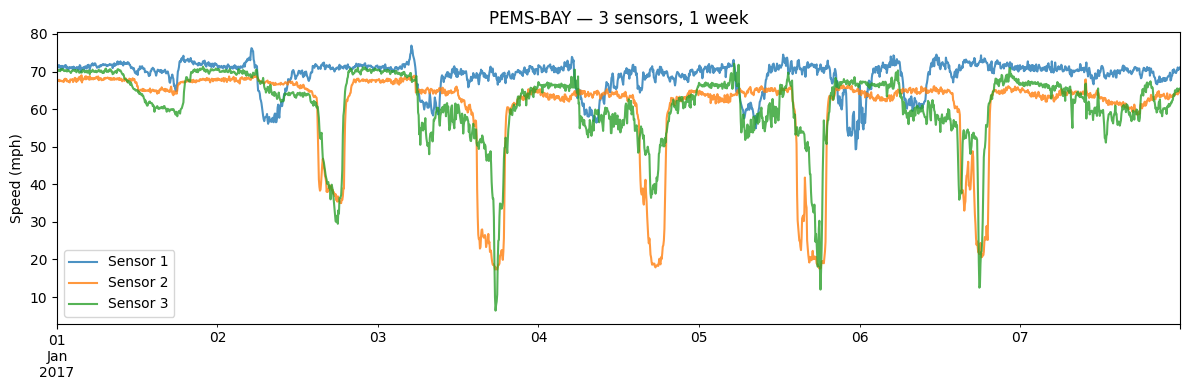

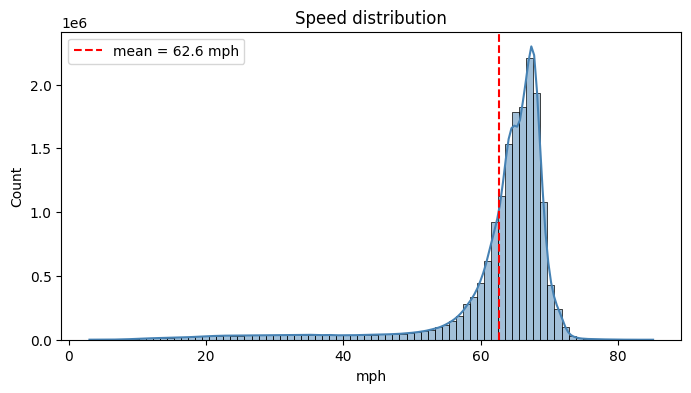

In [ ]:
# Quick visualisation — one week for 3 sensors
fig, ax = plt.subplots(figsize=(12, 4))
df.iloc[:7*24*12, :3].plot(ax=ax, alpha=0.8)
ax.set_ylabel('Speed (mph)'); ax.set_title('PEMS-BAY — 3 sensors, 1 week')
ax.legend(['Sensor 1', 'Sensor 2', 'Sensor 3']); plt.tight_layout(); plt.show()

vals = df.values[~missing_mask]
plt.figure(figsize=(8, 4))
sns.histplot(vals, bins=80, kde=True, color='steelblue')
plt.axvline(vals.mean(), color='r', ls='--', label=f'mean = {vals.mean():.1f} mph')
plt.title('Speed distribution'); plt.xlabel('mph'); plt.legend(); plt.show()

## 4. Data preparation


In [ ]:
# Data windowing and normalisation

SEQ_IN, SEQ_OUT = 12, 12   # 12 input steps (1 hour) -> 12 output steps
NUM_NODES = df.shape[1]     # 325 sensors

def build_windows(df, seq_in=12, seq_out=12):
    """Create sliding-window samples for sequence-to-sequence forecasting.

    Each window uses `seq_in` historical steps to predict `seq_out` future steps.
    Appends a time-of-day feature (fractional hour 0-1) as a second channel.

    Args:
        df:      DataFrame with DatetimeIndex, shape (T, N_sensors)
        seq_in:  Number of input time steps (default: 12 = 1 hour)
        seq_out: Number of output time steps (default: 12 = 1 hour)

    Returns:
        X: Input windows, shape (num_windows, seq_in, N, 2)
           Channel 0 = speed, Channel 1 = time-of-day
        Y: Target windows, shape (num_windows, seq_out, N)
           Speed values only (unnormalised)
    """
    speed = df.values.astype(np.float32)
    T, N = speed.shape

    # Time-of-day as fraction of 24-hour cycle [0, 1)
    tod = (df.index.values - df.index.values.astype('datetime64[D]')) / np.timedelta64(1, 'D')
    tod = tod.astype(np.float32)
    tod = np.tile(tod[:, None], (1, N))  # broadcast to all sensors
    data = np.stack([speed, tod], axis=-1)  # (T, N, 2)
    X, Y = [], []
    for t in range(T - seq_in - seq_out + 1):
        X.append(data[t : t + seq_in])
        Y.append(speed[t + seq_in : t + seq_in + seq_out])
    return np.stack(X), np.stack(Y)

X, Y = build_windows(df, SEQ_IN, SEQ_OUT)
print('Windows :', X.shape, Y.shape)

# Chronological 70/10/20 split (no shuffling — preserves temporal order)
S = X.shape[0]
n_train, n_val = int(S * 0.7), int(S * 0.1)
X_tr, Y_tr = X[:n_train], Y[:n_train]
X_va, Y_va = X[n_train:n_train+n_val], Y[n_train:n_train+n_val]
X_te, Y_te = X[n_train+n_val:], Y[n_train+n_val:]
print(f'Train {X_tr.shape[0]:,} | Val {X_va.shape[0]:,} | Test {X_te.shape[0]:,}')

# Verify chronological ordering (no data leakage)
print(f'Train period: index 0 to {n_train-1}')
print(f'Val period:   index {n_train} to {n_train+n_val-1}')
print(f'Test period:  index {n_train+n_val} to {S-1}')

# Z-score normalisation using ONLY training statistics
mean = X_tr[..., 0].mean(); std = X_tr[..., 0].std()
print(f'Train speed   mean={mean:.3f}  std={std:.3f}')

def normalise(arr):
    """Apply Z-score normalisation to the speed channel only.

    Uses training-set statistics (mean, std) to prevent data leakage.
    Time-of-day channel is left unchanged (already in [0, 1]).
    """
    arr = arr.copy()
    arr[..., 0] = (arr[..., 0] - mean) / std
    return arr

X_tr_n, X_va_n, X_te_n = map(normalise, (X_tr, X_va, X_te))

# Cache processed data for fast reloading in Milestone 3
np.savez_compressed('data/pems_bay_processed.npz',
                    X_tr=X_tr_n, Y_tr=Y_tr,
                    X_va=X_va_n, Y_va=Y_va,
                    X_te=X_te_n, Y_te=Y_te,
                    mean=mean, std=std)
print('Saved → data/pems_bay_processed.npz')

Windows : (52093, 12, 325, 2) (52093, 12, 325)
Train 36,465 | Val 5,209 | Test 10,419
Train period: index 0 to 36464
Val period:   index 36465 to 41673
Test period:  index 41674 to 52092
Train speed   mean=62.736  std=9.438
Saved → data/pems_bay_processed.npz


### 4.1 Adjacency matrix


In [ ]:
def asym_adj(adj):
    """Compute asymmetric (row-normalised) adjacency matrix.

    Each row is divided by its sum so that the diffusion operator
    preserves the total signal magnitude. This follows the convention
    in DCRNN (Li et al., 2018) and Graph WaveNet (Wu et al., 2019).

    Args:
        adj: Raw adjacency matrix, shape (N, N)
    Returns:
        Row-normalised adjacency, shape (N, N), dtype float32
    """
    adj = np.asarray(adj)
    rowsum = adj.sum(1).flatten()
    d_inv = np.power(rowsum, -1, where=rowsum!=0); d_inv[np.isinf(d_inv)] = 0
    return (np.diag(d_inv) @ adj).astype(np.float32)

if HAVE_ADJ:
    with open(ADJ_PATH, 'rb') as f:
        sensor_ids, sensor_id_to_ind, adj_mx = pickle.load(f, encoding='latin1')
    print('Adj :', adj_mx.shape, ' non-zeros:', (adj_mx > 0).sum())
    # Forward and backward diffusion supports (asymmetric normalisation)
    P_fwd = asym_adj(adj_mx); P_bwd = asym_adj(adj_mx.T)
    supports = [torch.tensor(P_fwd, device=device), torch.tensor(P_bwd, device=device)]
    print(f'Using FULL Graph WaveNet (static + adaptive), {len(supports)} supports.')
else:
    P_fwd = P_bwd = None
    supports = []
    print('Using ADAPTIVE-ONLY Graph WaveNet variant (no static adjacency).')

Adj : (325, 325)  non-zeros: 2694
Using FULL Graph WaveNet (static + adaptive), 2 supports.


## 5. Model — Graph WaveNet


In [ ]:
# Graph WaveNet model definition (Wu et al., IJCAI 2019)

class NConv(nn.Module):
    """Neighbourhood convolution: applies a graph shift operator (adjacency
    multiplication) to node features using Einstein summation for efficiency.

    Input:  x of shape (B, C, N, T) and adjacency A of shape (N, N)
    Output: Graph-shifted features of shape (B, C, N, T)
    """
    def forward(self, x, A):
        return torch.einsum('ncvl,vw->ncwl', x, A).contiguous()

class Linear(nn.Module):
    """1x1 convolution wrapper for channel mixing without spatial/temporal
    interaction. Equivalent to a shared linear layer across all nodes and steps."""
    def __init__(self, c_in, c_out):
        super().__init__(); self.mlp = nn.Conv2d(c_in, c_out, (1, 1), bias=True)
    def forward(self, x): return self.mlp(x)

class GCN(nn.Module):
    """K-hop diffusion graph convolution.

    Aggregates information from K-hop neighbours using multiple graph supports
    (forward, backward, adaptive). Each hop is computed iteratively via
    repeated application of the neighbourhood convolution. The aggregated
    features from all hops are concatenated and mixed via a 1x1 convolution.

    Args:
        c_in:        Input channels
        c_out:       Output channels
        dropout:     Dropout rate applied after the MLP
        support_len: Number of graph support matrices (2 static + 1 adaptive = 3)
        order:       Diffusion order K (number of hops per support)
    """
    def __init__(self, c_in, c_out, dropout, support_len=2, order=2):
        super().__init__()
        self.nconv = NConv()
        self.mlp = Linear((order * support_len + 1) * c_in, c_out)
        self.dropout, self.order = dropout, order
    def forward(self, x, supports):
        out = [x]  # include identity (0-hop)
        for A in supports:
            x1 = self.nconv(x, A); out.append(x1)
            for _ in range(self.order - 1):
                x1 = self.nconv(x1, A); out.append(x1)
        return F.dropout(self.mlp(torch.cat(out, dim=1)), self.dropout, training=self.training)

class GraphWaveNet(nn.Module):
    """Graph WaveNet: Adaptive adjacency + dilated causal TCN + GCN diffusion.

    Key innovations over prior work (DCRNN, STGCN):
    - Adaptive adjacency matrix learned end-to-end via node embeddings
    - Gated temporal convolution (WaveNet-style tanh * sigmoid activation)
    - Skip connections accumulated across all layers for gradient flow
    - Diffusion-style graph convolution with K-hop aggregation

    Args:
        num_nodes: Number of sensors/nodes in the graph (325 for PEMS-BAY)
        in_dim:    Input feature dimension (2: speed + time-of-day)
        out_dim:   Number of future time steps to predict (12)
        residual:  Residual channel dimension (32)
        dilation:  Dilation channel dimension (32)
        skip:      Skip connection channel dimension (256)
        end:       End convolution channel dimension (512)
        blocks:    Number of TCN blocks (4)
        layers:    Layers per block with exponentially growing dilation (2)
        kernel:    Temporal convolution kernel size (2)
        dropout:   Dropout rate (0.3)
        supports:  List of pre-computed adjacency matrices [P_fwd, P_bwd]
        adp_emb:   Adaptive adjacency embedding dimension (10)
    """
    def __init__(self, num_nodes, in_dim=2, out_dim=12, residual=32, dilation=32,
                 skip=256, end=512, blocks=4, layers=2, kernel=2,
                 dropout=0.3, supports=None, adp_emb=10):
        super().__init__()
        self.blocks, self.layers, self.dropout = blocks, layers, dropout
        self.supports = supports if supports is not None else []
        # Initial 1x1 conv to lift input features to residual channels
        self.start_conv = nn.Conv2d(in_dim, residual, (1, 1))
        # Learnable node embeddings for adaptive adjacency
        self.E1 = nn.Parameter(torch.randn(num_nodes, adp_emb))
        self.E2 = nn.Parameter(torch.randn(adp_emb, num_nodes))
        # Module lists for the stacked TCN layers
        self.filter_convs, self.gate_convs = nn.ModuleList(), nn.ModuleList()
        self.residual_convs, self.skip_convs = nn.ModuleList(), nn.ModuleList()
        self.bn, self.gconv = nn.ModuleList(), nn.ModuleList()
        rf = 1  # receptive field counter
        for _ in range(blocks):
            d = 1  # dilation resets to 1 in each block
            for _ in range(layers):
                self.filter_convs.append(nn.Conv2d(residual, dilation, (1, kernel), dilation=d))
                self.gate_convs.append(  nn.Conv2d(residual, dilation, (1, kernel), dilation=d))
                self.residual_convs.append(nn.Conv2d(dilation, residual, (1, 1)))
                self.skip_convs.append(    nn.Conv2d(dilation, skip,     (1, 1)))
                self.bn.append(nn.BatchNorm2d(residual))
                self.gconv.append(GCN(dilation, residual, dropout, support_len=len(self.supports)+1))
                rf += d * (kernel - 1); d *= 2  # exponential dilation growth
        self.receptive_field = rf
        self.end_conv_1 = nn.Conv2d(skip, end,     (1, 1))  # skip -> end channels
        self.end_conv_2 = nn.Conv2d(end,  out_dim, (1, 1))  # end -> 12 output steps

    def forward(self, x):
        """Forward pass.

        Args:
            x: Input tensor, shape (B, T=12, N=325, F=2)
               Channel 0: normalised speed
               Channel 1: time-of-day [0, 1)

        Returns:
            Predictions, shape (B, N, T_out=12) — unnormalised predicted speeds
            must be de-normalised externally: pred * std + mean
        """
        x = x.permute(0, 3, 2, 1)  # -> (B, F, N, T) for Conv2d
        # Pad temporally if input is shorter than receptive field
        if x.size(3) < self.receptive_field:
            x = F.pad(x, (self.receptive_field - x.size(3), 0, 0, 0))
        x = self.start_conv(x); skip = 0
        # Adaptive adjacency: softmax(ReLU(E1 * E2))
        adp = F.softmax(F.relu(torch.mm(self.E1, self.E2)), dim=1)
        supports = self.supports + [adp]
        # Process through stacked TCN blocks
        for i in range(self.blocks * self.layers):
            res = x
            # Gated activation: tanh(filter) * sigmoid(gate)
            f = torch.tanh(self.filter_convs[i](res))
            g = torch.sigmoid(self.gate_convs[i](res))
            x = f * g
            # Accumulate skip connections
            s = self.skip_convs[i](x)
            skip = s if isinstance(skip, int) else s + skip[..., -s.size(3):]
            # Graph convolution + residual connection + batch norm
            x = self.gconv[i](x, supports)
            x = x + res[..., -x.size(3):]
            x = self.bn[i](x)
        # Output head: ReLU -> 1x1 conv -> ReLU -> 1x1 conv
        x = F.relu(skip)
        x = F.relu(self.end_conv_1(x))
        x = self.end_conv_2(x)
        return x.squeeze(-1).permute(0, 2, 1)  # -> (B, N, T_out)

In [ ]:
model = GraphWaveNet(num_nodes=NUM_NODES, in_dim=2, out_dim=SEQ_OUT,
                     supports=supports).to(device)
print(f'Trainable parameters: {sum(p.numel() for p in model.parameters()):,}')
print(f'Receptive field      : {model.receptive_field}')
print(f'Graph variant        : {"full (static + adaptive)" if HAVE_ADJ else "adaptive-only"}')

Trainable parameters: 311,760
Receptive field      : 13
Graph variant        : full (static + adaptive)


## 6. Training


In [ ]:
# Training setup

BATCH = 32

# DataLoaders with appropriate settings:
# - Training: shuffle=True for SGD, drop_last=True for consistent batch sizes
# - Validation/Test: shuffle=False to preserve temporal order
tr_loader = DataLoader(TensorDataset(torch.tensor(X_tr_n), torch.tensor(Y_tr)),
                       batch_size=BATCH, shuffle=True, drop_last=True)
va_loader = DataLoader(TensorDataset(torch.tensor(X_va_n), torch.tensor(Y_va)),
                       batch_size=BATCH, shuffle=False)
te_loader = DataLoader(TensorDataset(torch.tensor(X_te_n), torch.tensor(Y_te)),
                       batch_size=BATCH, shuffle=False)

def masked_mae(pred, true, null=0.0):
    """Mean Absolute Error with masking for missing (zero-valued) entries.

    PEMS-BAY uses 0.0 to indicate missing sensor readings. These entries
    are excluded from the loss to prevent the model from learning to predict
    zero for missing data.
    """
    mask = (true != null).float(); mask /= mask.mean().clamp(min=1e-4)
    loss = torch.abs(pred - true) * mask
    return torch.where(torch.isnan(loss), torch.zeros_like(loss), loss).mean()

def masked_rmse(pred, true, null=0.0):
    """Root Mean Squared Error with masking for missing values."""
    mask = (true != null).float(); mask /= mask.mean().clamp(min=1e-4)
    loss = (pred - true) ** 2 * mask
    return torch.sqrt(torch.where(torch.isnan(loss), torch.zeros_like(loss), loss).mean())

def masked_mape(pred, true, null=0.0):
    """Mean Absolute Percentage Error with masking for missing values."""
    mask = (true != null).float(); mask /= mask.mean().clamp(min=1e-4)
    loss = torch.abs((pred - true) / true.clamp(min=1e-4)) * mask
    return torch.where(torch.isnan(loss), torch.zeros_like(loss), loss).mean()

# Optimiser: Adam with weight decay for L2 regularisation
optim = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)
# LR schedule: halve at epochs 20, 30, 40, 50 for fine-grained convergence
sched = torch.optim.lr_scheduler.MultiStepLR(optim, milestones=[20, 30, 40, 50], gamma=0.5)

history = {'tr_loss': [], 'va_loss': [], 'va_rmse': [], 'va_mape': []}
best_va, patience, wait = float('inf'), 12, 0
EPOCHS = 60

for epoch in range(1, EPOCHS+1):
    # --- Training phase ---
    model.train(); t0 = time.time(); tot = 0; n = 0
    for xb, yb in tr_loader:
        xb, yb = xb.to(device), yb.to(device)
        optim.zero_grad()
        out = model(xb).permute(0, 2, 1) * std + mean  # de-normalise predictions
        loss = masked_mae(out, yb)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), 5.0)  # prevent exploding gradients
        optim.step()
        tot += loss.item() * xb.size(0); n += xb.size(0)
    tr_loss = tot / n

    # --- Validation phase ---
    model.eval(); v_mae = v_rmse = v_mape = 0; n = 0
    with torch.no_grad():
        for xb, yb in va_loader:
            xb, yb = xb.to(device), yb.to(device)
            out = model(xb).permute(0, 2, 1) * std + mean
            v_mae  += masked_mae (out, yb).item() * xb.size(0)
            v_rmse += masked_rmse(out, yb).item() * xb.size(0)
            v_mape += masked_mape(out, yb).item() * xb.size(0)
            n += xb.size(0)
    v_mae, v_rmse, v_mape = v_mae/n, v_rmse/n, v_mape/n
    sched.step()

    history['tr_loss'].append(tr_loss); history['va_loss'].append(v_mae)
    history['va_rmse'].append(v_rmse); history['va_mape'].append(v_mape)
    print(f'Ep {epoch:02d} | tr {tr_loss:.3f} | va MAE {v_mae:.3f} '
          f'RMSE {v_rmse:.3f} MAPE {v_mape*100:.2f}% | {time.time()-t0:.1f}s')

    # Early stopping: save best model and stop if no improvement
    if v_mae < best_va:
        best_va, wait = v_mae, 0
        torch.save(model.state_dict(), 'best_gwn_bay.pth')
    else:
        wait += 1
        if wait >= patience: print('Early stop'); break

print(f'\nBest validation MAE: {best_va:.3f} mph')

Ep 01 | tr 1.983 | va MAE 1.999 RMSE 4.058 MAPE 4.64% | 202.6s
Ep 02 | tr 1.823 | va MAE 1.947 RMSE 3.891 MAPE 4.58% | 204.1s
Ep 03 | tr 1.768 | va MAE 1.855 RMSE 3.731 MAPE 4.29% | 205.3s
Ep 04 | tr 1.718 | va MAE 1.845 RMSE 3.661 MAPE 4.59% | 204.3s
Ep 05 | tr 1.673 | va MAE 1.766 RMSE 3.517 MAPE 4.01% | 203.9s
Ep 06 | tr 1.645 | va MAE 1.731 RMSE 3.462 MAPE 4.03% | 204.3s
Ep 07 | tr 1.625 | va MAE 1.717 RMSE 3.406 MAPE 4.01% | 204.7s
Ep 08 | tr 1.609 | va MAE 1.709 RMSE 3.416 MAPE 3.98% | 205.0s
Ep 09 | tr 1.594 | va MAE 1.710 RMSE 3.430 MAPE 3.93% | 204.5s
Ep 10 | tr 1.583 | va MAE 1.687 RMSE 3.417 MAPE 3.90% | 204.9s
Ep 11 | tr 1.571 | va MAE 1.686 RMSE 3.351 MAPE 3.96% | 204.3s
Ep 12 | tr 1.564 | va MAE 1.678 RMSE 3.400 MAPE 3.96% | 204.4s
Ep 13 | tr 1.555 | va MAE 1.647 RMSE 3.337 MAPE 3.71% | 204.5s
Ep 14 | tr 1.547 | va MAE 1.654 RMSE 3.352 MAPE 3.77% | 205.0s
Ep 15 | tr 1.540 | va MAE 1.654 RMSE 3.334 MAPE 3.71% | 204.7s
Ep 16 | tr 1.534 | va MAE 1.644 RMSE 3.327 MAPE 3.85% |

## 7. Training curves

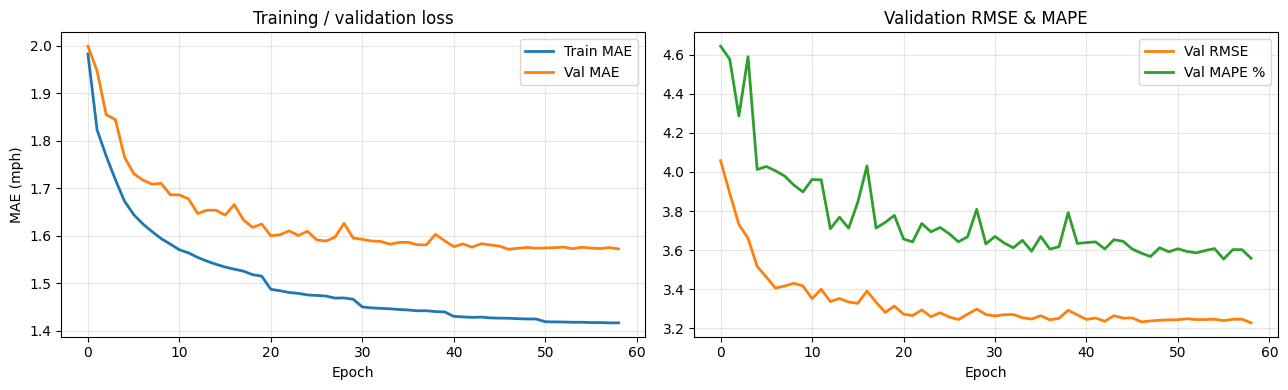

In [ ]:
fig, ax = plt.subplots(1, 2, figsize=(13, 4))
ax[0].plot(history['tr_loss'], label='Train MAE', lw=2)
ax[0].plot(history['va_loss'], label='Val MAE',   lw=2)
ax[0].set_xlabel('Epoch'); ax[0].set_ylabel('MAE (mph)')
ax[0].set_title('Training / validation loss'); ax[0].legend(); ax[0].grid(alpha=.3)
ax[1].plot(history['va_rmse'], label='Val RMSE', lw=2, color='tab:orange')
ax[1].plot([m*100 for m in history['va_mape']], label='Val MAPE %', lw=2, color='tab:green')
ax[1].set_xlabel('Epoch'); ax[1].set_title('Validation RMSE & MAPE')
ax[1].legend(); ax[1].grid(alpha=.3)
plt.tight_layout(); plt.savefig('training_curves_bay.png', dpi=140); plt.show()

## 8. Test-set evaluation

In [ ]:
# Test-set evaluation — load best checkpoint and run inference

model.load_state_dict(torch.load('best_gwn_bay.pth', map_location=device))
model.eval()
preds, trues = [], []
with torch.no_grad():
    for xb, yb in te_loader:
        out = model(xb.to(device)).permute(0, 2, 1) * std + mean
        preds.append(out.cpu()); trues.append(yb)
preds = torch.cat(preds); trues = torch.cat(trues)

# Report per-horizon metrics at the standard benchmarking points
rows = []
for h, label in [(2, '15-min'), (5, '30-min'), (11, '60-min')]:
    p, t = preds[:, h], trues[:, h]
    rows.append([label, masked_mae(p, t).item(),
                 masked_rmse(p, t).item(), masked_mape(p, t).item() * 100])
results = pd.DataFrame(rows, columns=['Horizon', 'MAE', 'RMSE', 'MAPE (%)'])
print('\n=== TEST PERFORMANCE ===')
print(results.to_string(index=False))
results.to_csv('test_results_bay.csv', index=False)

print('\nReference numbers (Wu et al., IJCAI 2019):')
print('  15-min: MAE 1.30 | RMSE 2.74 | MAPE 2.73%')
print('  30-min: MAE 1.63 | RMSE 3.70 | MAPE 3.67%')
print('  60-min: MAE 1.95 | RMSE 4.52 | MAPE 4.63%')


=== TEST PERFORMANCE ===
Horizon      MAE     RMSE  MAPE (%)
 15-min 1.299699 2.737179  2.707518
 30-min 1.625219 3.698619  3.662275
 60-min 1.925668 4.466409  4.572244

Reference numbers (Wu et al., IJCAI 2019):
  15-min: MAE 1.30 | RMSE 2.74 | MAPE 2.73%
  30-min: MAE 1.63 | RMSE 3.70 | MAPE 3.67%
  60-min: MAE 1.95 | RMSE 4.52 | MAPE 4.63%


In [ ]:
# Baselines — Historical Average and Last-value persistence

# Baseline 1: Historical Average — predicts the global mean speed per sensor
ha_pred = np.tile(df.values.mean(0), (preds.shape[0], SEQ_OUT, 1))
ha_pred = torch.tensor(ha_pred, dtype=torch.float32)

# Baseline 2: Last-value (persistence) — repeats the last OBSERVED speed
# IMPORTANT: Use the last INPUT observation, NOT the ground truth!
# X_te_n[:, -1, :, 0] is the normalised speed at the final input step
last_speed = torch.tensor(X_te_n[:, -1, :, 0]) * std + mean  # de-normalise
lv_pred = last_speed[:, None, :].expand_as(trues)

# Comparison table
rows = [['Historical Average',       masked_mae(ha_pred, trues).item(), masked_rmse(ha_pred, trues).item()],
        ['Last-value (persistence)', masked_mae(lv_pred, trues).item(), masked_rmse(lv_pred, trues).item()],
        ['Graph WaveNet (avg)',      masked_mae(preds, trues).item(),   masked_rmse(preds, trues).item()]]
print(pd.DataFrame(rows, columns=['Model', 'MAE', 'RMSE']).to_string(index=False))

# Quantify Graph WaveNet's improvement over baselines
gwn_mae = rows[2][1]
for bname, bmae in [('HA', rows[0][1]), ('Last-value', rows[1][1])]:
    pct = (bmae - gwn_mae) / bmae * 100
    print(f'Graph WaveNet beats {bname} by {pct:.1f}%')

In [ ]:
# Qualitative visualisation — one sensor, one day
# Shows how the model tracks real traffic patterns including
# rush-hour congestion dips and overnight free-flow recovery

sensor = 50; horizon = 2; day = 24 * 12  # 24 hours of 5-min steps
plt.figure(figsize=(12, 4))
plt.plot(trues[:day, horizon, sensor].numpy(), label='Ground truth', lw=2)
plt.plot(preds[:day, horizon, sensor].numpy(), label='Prediction',   lw=2, alpha=.8)
plt.xlabel('Time-step (5-min)'); plt.ylabel('Speed (mph)')
plt.title(f'Sensor {sensor} — 15-minute ahead forecast (1 day)')
plt.legend(); plt.grid(alpha=.3); plt.tight_layout()
plt.savefig('qualitative_prediction_bay.png', dpi=140); plt.show()

## 9. Save checkpoint for Milestone 3

In [ ]:
# Save comprehensive checkpoint for Milestone 3
# Includes model weights, normalisation stats, graph supports,
# and dataset metadata for complete reproducibility

torch.save({
    'state_dict': model.state_dict(),
    'mean': float(mean), 'std': float(std),
    'num_nodes': NUM_NODES, 'seq_in': SEQ_IN, 'seq_out': SEQ_OUT,
    'P_fwd': P_fwd, 'P_bwd': P_bwd,
    'have_adj': HAVE_ADJ,
    'dataset': 'PEMS-BAY',
}, 'gwn_pems_bay.ckpt')
print('Checkpoint saved → gwn_pems_bay.ckpt')

# Copy artefacts to Google Drive for safekeeping
try:
    shutil.copy('gwn_pems_bay.ckpt', DRIVE_DIR)
    shutil.copy('data/pems_bay_processed.npz', DRIVE_DIR)
    print(f'Also copied to {DRIVE_DIR}')
except Exception as e:
    print('Could not copy back to Drive:', e)